# 🎮 Гейминг и когнитивные способности
Добро пожаловать в проект, посвященный исследованию влияния видеоигр на когнитивные способности и академическую успеваемость!




## Этап 1: Загрузка, очистка и базовая предобработка данных
На этом этапе мы:
1. Загрузим необходимые библиотеки и сам датасет.
2. Проверим данные на наличие пропусков и дубликатов.
3. Обработаем аномалии (выбросы).

In [2]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings

# Настройка визуального стиля для графиков
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Отключаем лишние предупреждения для чистоты вывода
warnings.filterwarnings('ignore')

print("✅ Библиотеки успешно загружены и настроены!")

ModuleNotFoundError: No module named 'pandas'

### 1.1 Загрузка данных
Для удобства работы и полной воспроизводимости проекта мы не будем загружать файл локально, а скачаем его напрямую из нашего репозитория на GitHub.

In [2]:
# Прямая ссылка на датасет в репозитории GitHub
url = 'https://raw.githubusercontent.com/Quantezzy/Gaming-and-cognitive-functions/refs/heads/main/data/dataset.csv'

try:
    df = pd.read_csv(url)
    print(f"✅ Данные успешно загружены! Размер датасета: {df.shape[0]} строк",
    f"и {df.shape[1]} колонок.")
except Exception as e:
    print(f"❌ Произошла ошибка при загрузке файла: {e}")

# Посмотрим на первые 5 строк, чтобы убедиться, что всё считалось корректно
df.head()

✅ Данные успешно загружены! Размер датасета: 8000 строк и 14 колонок.


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


### 1.2 Первичный осмотр и проверка качества данных
Чтобы доверять результатам исследования, нам нужно убедиться в чистоте данных. Проверим типы колонок, поищем пропуски и дубликаты.

In [3]:
# Общая информация о датасете (типы данных, пропуски)
print("--- Информация о датасете ---")
df.info()
print("\n")

# Проверка на дубликаты
duplicates_count = df.duplicated().sum()
print(f"Количество полных дубликатов в данных: {duplicates_count}")

# Проверка на пропущенные значения
missing_values = df.isna().sum()
if missing_values.sum() == 0:
    print("Пропущенных значений нет.")
else:
    print(f"Кол-во пропущенных значений: {missing_values}.")

--- Информация о датасете ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


Количество полных дубликатов в данных: 0
Проп

### 1.3 Обработка аномалий
При беглом взгляде на выборку можно заметить две вещи:
1. Колонка `student_id` является просто идентификатором и не несет ценности для машинного обучения и статистики — удалим её.
2. В колонке `grades` встречаются значения больше 100 (выбросы/ошибки ввода). Чтобы не искажать распределение скейлерами или обрезкой, мы применим классический метод: **удаление аномалий**. Мы просто отфильтруем датасет, оставив только реалистичные оценки от 0 до 100.

In [4]:
# 1. Удаление неинформативных колонок
if 'student_id' in df.columns:
    df.drop('student_id', axis=1, inplace=True)
    print("Колонка 'student_id' успешно удалена.")

# 2. Удаление выбросов в оценках (>100 баллов)
outliers_count = df[df['grades'] > 100].shape[0]
df = df[df['grades'] <= 100.0]
print(f"✅ Удалено {outliers_count} аномальных записей с оценкой > 100.")

# Округлим некоторые показатели до 2 знаков для аккуратности визуализации
cols_to_round = ['gaming_hours', 'study_hours', 'sleep_hours', 'grades',
                 'reaction_time_ms']
df[cols_to_round] = df[cols_to_round].round(2)

# Посмотрим на описательную статистику очищенных данных
df.describe().T

Колонка 'student_id' успешно удалена.
✅ Удалено 134 аномальных записей с оценкой > 100.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,count,mean,std,min,25%,50%,75%,max
age,7866.0,19.985507,2.587474,16.00,18.0000,20.000,22.0000,24.00
gaming_hours,7866.0,4.110071,2.305259,0.00,2.1700,4.170,6.0875,8.00
study_hours,7866.0,5.406250,2.559204,1.00,3.1900,5.375,7.5600,10.00
sleep_hours,7866.0,6.478472,1.441767,4.00,5.2300,6.480,7.7100,9.00
attendance,7866.0,79.810964,11.574376,60.00,69.7300,79.560,89.9875,100.00
social_activity,7866.0,2.506372,1.440591,0.00,1.2825,2.500,3.7600,5.00
device_usage,7866.0,7.608656,2.708336,1.10,5.5900,7.640,9.6100,13.95
reaction_time_ms,7866.0,270.825114,29.404172,183.26,246.8625,270.130,294.3100,347.87
addiction_score,7866.0,9.954681,5.033861,-4.51,5.9900,10.070,13.9000,23.16
grades,7866.0,65.502604,21.992798,0.00,49.5100,66.535,83.2100,100.00


**Вывод по Этапу 1:**
Мы успешно загрузили и подготовили наши данные. Датасет оказался довольно чистым: без пропусков и дубликатов. Мы избавились от технического мусора, ограничили аномальные значения оценок рамками 0-100 и задали верную иерархию для категориального признака уровня стресса.

Теперь данные готовы к следующим этапам.

## Этап 2: Разведочный анализ данных (EDA) и визуализация

На этом этапе мы посмотрим на наши данные через призму графиков. Визуализация поможет нам:
1. Понять распределение ключевых переменных (оценки, часы игры, скорость реакции).
2. Оценить матрицу корреляций — какие числовые признаки связаны друг с другом сильнее всего.
3. Сравнить показатели игроков разных жанров (FPS, RPG, Casual).
4. Увидеть влияние побочных факторов, таких как сон и стресс.

### 2.1 Распределение ключевых метрик
Для начала давайте посмотрим на "портрет" наших данных. Как распределяются часы, проведенные за играми, успеваемость и скорость реакции?

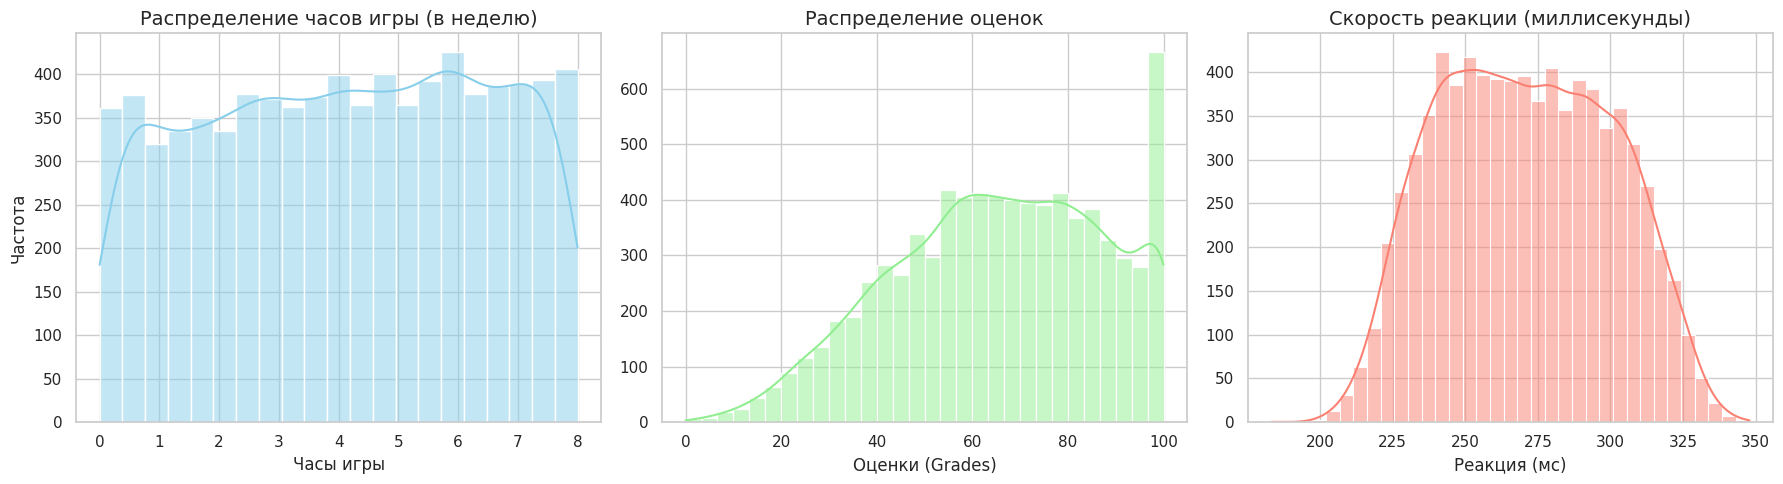

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Распределение часов игры
sns.histplot(data=df, x='gaming_hours', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение часов игры (в неделю)')
axes[0].set_xlabel('Часы игры')
axes[0].set_ylabel('Частота')

# График 2: Распределение успеваемости
sns.histplot(data=df, x='grades', kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Распределение оценок')
axes[1].set_xlabel('Оценки (Grades)')
axes[1].set_ylabel('')

# График 3: Распределение скорости реакции
sns.histplot(data=df, x='reaction_time_ms', kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Скорость реакции (миллисекунды)')
axes[2].set_xlabel('Реакция (мс)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

**💡 Аналитический вывод:**
* **Часы игры:** Распределение практически равномерное. Это отличная новость для нашего исследования — в выборке одинаково хорошо представлены как негеймеры (0-1 час), так и заядлые игроки (7-8 часов). Нам не грозит дисбаланс данных при сравнении этих групп.
* **Оценки:** Наблюдается левосторонняя асимметрия — основная масса студентов учится выше среднего. Выраженный пик на отметке 100 баллов демонстрирует классический «эффект потолка» (ceiling effect) системы оценивания, когда сильные студенты упираются в максимальный балл.
* **Скорость реакции:** Демонстрирует идеальное нормальное распределение, что типично для физиологических метрик человека. Основная масса значений лежит в пределах 235–300 мс.

### 2.2 Корреляционный анализ
Теперь построим тепловую карту (Heatmap) корреляций. Это один из важнейших инструментов аналитика.
Коэффициент Пирсона покажет линейную зависимость между числовыми переменными.

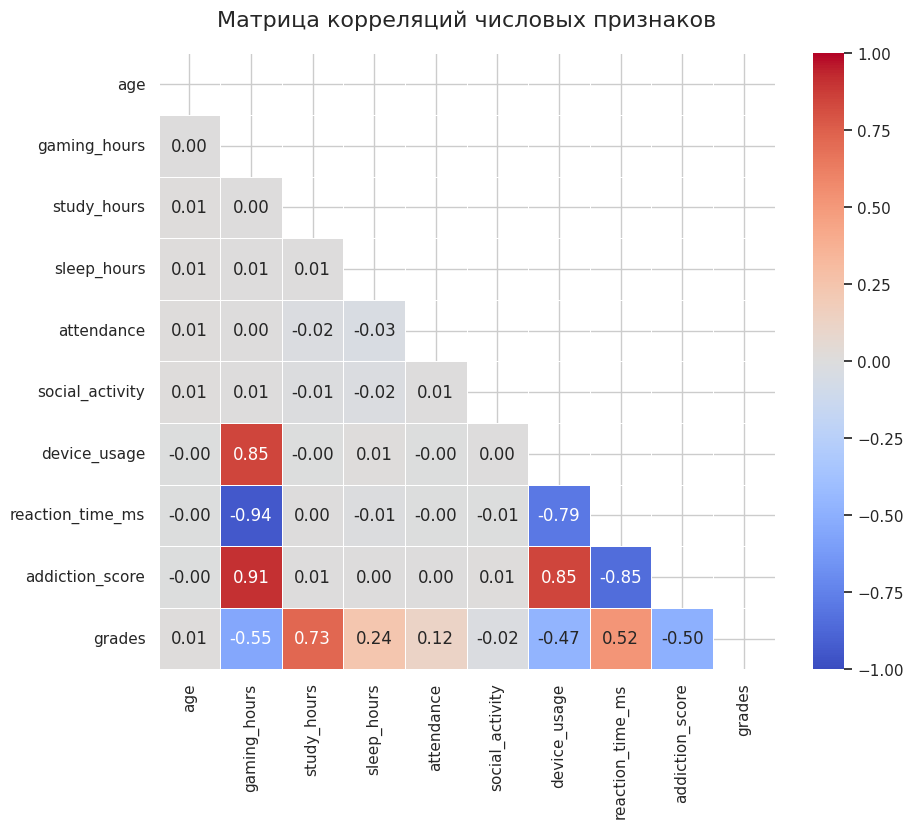

In [6]:
# Выбираем только числовые колонки для корреляции
num_df = df.select_dtypes(include=[np.number])

# Считаем матрицу корреляций
corr = num_df.corr()

# Создаем маску для скрытия верхнего треугольника (чтобы график был чище)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5)

plt.title('Матрица корреляций числовых признаков', fontsize=16, pad=20)
plt.show()

**💡 Аналитический вывод:**
* **Двойственный эффект гейминга:** Мы видим подтверждение сразу двух гипотез. Часы игры (`gaming_hours`) имеют обратную связь с оценками (-0.55), но при этом показывают мощнейшую отрицательную корреляцию с `reaction_time_ms` (-0.94). Напомним: чем *меньше* миллисекунд, тем *быстрее* реакция. Это сильный аргумент в пользу того, что игры действительно "разгоняют" когнитивно-моторные навыки.
* **Разрушение социального стереотипа:** Обратите внимание на нулевую корреляцию гейминга с `social_activity`, `sleep_hours`, `study_hours` и `attendance`. В нашей выборке геймеры не являются "недосыпающими интровертами, забившими на учёбу" — их социальная жизнь, сон и учёба не страдают от хобби.
* **Ложная корреляция:** Может показаться странным, что медленная реакция (высокий `reaction_time_ms`) положительно связана с высокими оценками (0.52). Но это классическое "смешивание": просто отличники много учатся (`study_hours` с `grades` = 0.73) и мало играют, из-за чего их скорость реакции остается на базовом уровне.
* **Предупреждение мультиколлинеарности:** Признаки `gaming_hours`, `device_usage` и `addiction_score` дублируют друг друга (корреляции 0.85–0.91). Для построения модели предсказания оценок, нам придется оставить только один из этих параметров, чтобы избежать мультиколлинеарности и нестабильности алгоритма. Мы видим, что признаки `device_usage` и `addiction_score` не несут никакой дополнительной информации, а признак `gaming_hours` является одним из базовых в соответствии с нашей темой. Поэтому оставим именно его.

In [7]:
# Удаление дублирующих признаков
if 'device_usage' in df.columns:
    df.drop('device_usage', axis=1, inplace=True)
    print("Колонка 'device_usage' успешно удалена.")
if 'addiction_score' in df.columns:
    df.drop('addiction_score', axis=1, inplace=True)
    print("Колонка 'addiction_score' успешно удалена.")

Колонка 'device_usage' успешно удалена.
Колонка 'addiction_score' успешно удалена.


### 2.3 Влияние жанра игры на когнитивные метрики
Не все игры одинаковы. Шутеры от первого лица (FPS) требуют невероятной скорости реакции, тогда как RPG или казуальные игры могут быть более размеренными. Давайте проверим, отражается ли это на наших студентах.

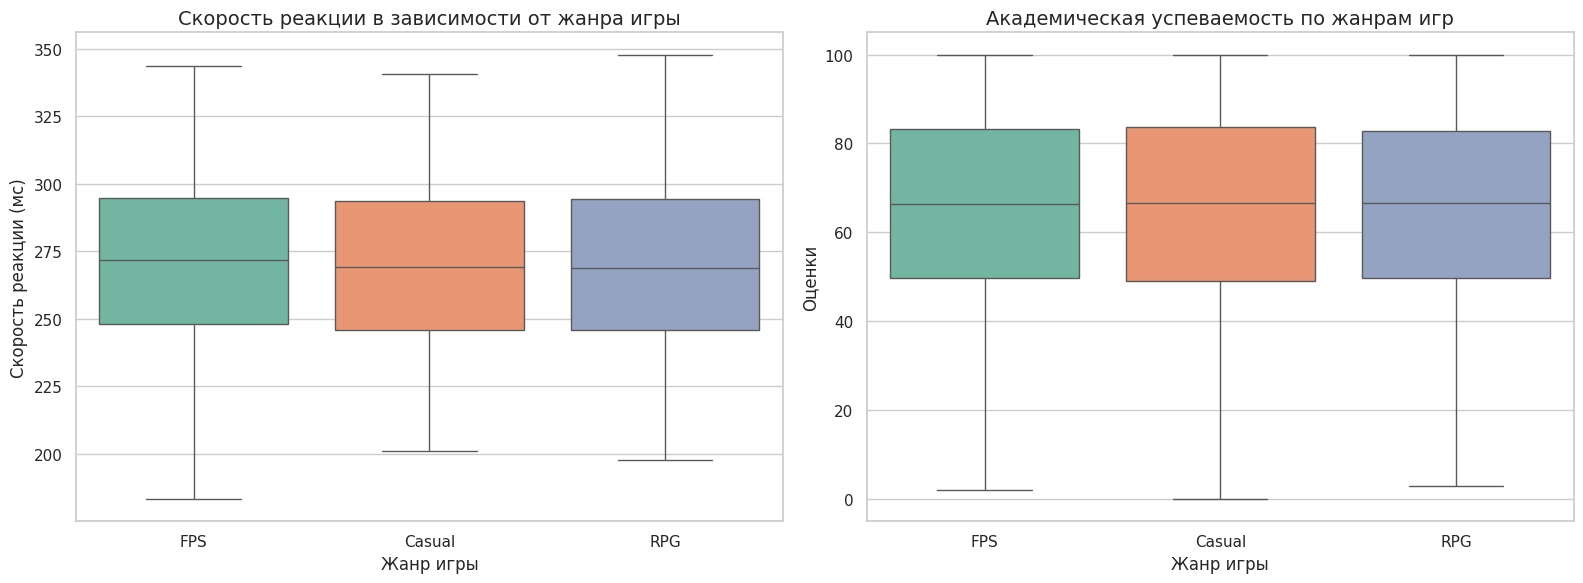

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Жанр и скорость реакции
# Используем boxplot, чтобы увидеть медиану и разброс
sns.boxplot(data=df, x='gaming_genre', y='reaction_time_ms', ax=axes[0],
            palette='Set2')
axes[0].set_title('Скорость реакции в зависимости от жанра игры')
axes[0].set_xlabel('Жанр игры')
axes[0].set_ylabel('Скорость реакции (мс)')

# График 2: Жанр и оценки
sns.boxplot(data=df, x='gaming_genre', y='grades', ax=axes[1], palette='Set2')
axes[1].set_title('Академическая успеваемость по жанрам игр')
axes[1].set_xlabel('Жанр игры')
axes[1].set_ylabel('Оценки')

plt.tight_layout()
plt.show()

**💡 Аналитический вывод:**
* **Опровержение стереотипа о жанрах:** Наша изначальная гипотеза о том, что любители динамичных шутеров (FPS) обладают значительно более быстрой реакцией, разбивается о данные. Медианы и межквартильные размахи практически идентичны для всех трех жанров. Это говорит о том, что тренирует реакцию *само время, проведенное за играми* (что мы видели в корреляции), а не конкретный *жанр*.
* **Нулевая предиктивная сила признака:** Распределение оценок также абсолютно не зависит от предпочитаемого жанра игры. Если студент получает плохие оценки, это никак не связано с тем, играет ли он в "тяжелые" RPG или простенькие Casual-игры.
* **Машинное обучение:** Визуальное отсутствие разницы между группами — четкий сигнал для нас как для аналитиков. Признак `gaming_genre` имеет нулевую "важность". Эту колонку можно будет смело удалить при построении модели машинного обучения, чтобы не усложнять алгоритм бесполезным шумом.

### 2.4 Вмешивающийся фактор: Уровень стресса

Давайте посмотрим, как уровень стресса отражается на академической успеваемости и склонности к геймингу (возможно, игры используются как способ справиться со стрессом?).

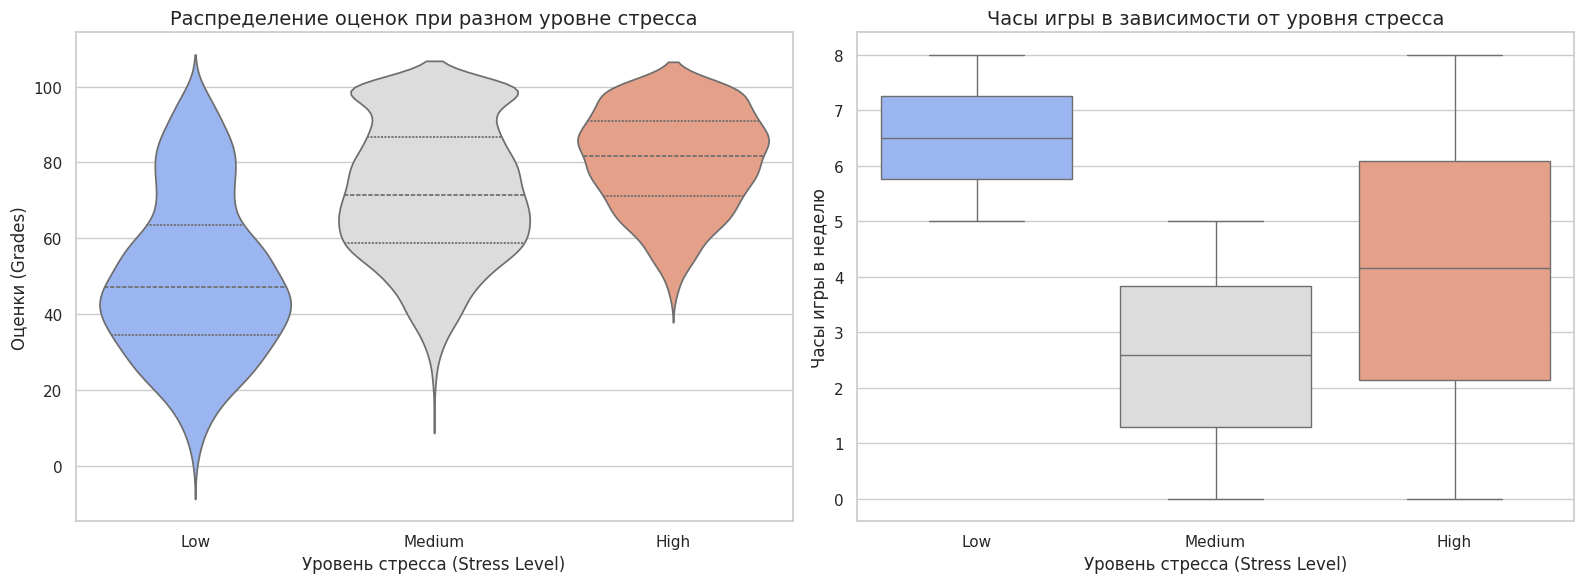

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Стресс и оценки (используем Violinplot для оценки плотности
#                                                                распределения)
sns.violinplot(data=df, x='stress_level', y='grades', ax=axes[0],
               palette='coolwarm', inner='quartile')
axes[0].set_title('Распределение оценок при разном уровне стресса', fontsize=14)
axes[0].set_xlabel('Уровень стресса (Stress Level)', fontsize=12)
axes[0].set_ylabel('Оценки (Grades)', fontsize=12)

# График 2: Стресс и часы игры (Boxplot для сравнения медиан)
sns.boxplot(data=df, x='stress_level', y='gaming_hours', ax=axes[1],
            palette='coolwarm')
axes[1].set_title('Часы игры в зависимости от уровня стресса', fontsize=14)
axes[1].set_xlabel('Уровень стресса (Stress Level)', fontsize=12)
axes[1].set_ylabel('Часы игры в неделю', fontsize=12)

plt.tight_layout()
plt.show()

**💡 Аналитический вывод:**
* **«Парадокс отличника» (Стресс и Оценки):** Левый график показывает контринтуитивную, но очень логичную картину. Уровень стресса *прямо пропорционален* успеваемости! Студенты с высоким (High) и средним (Medium) уровнем стресса имеют самые высокие баллы. А вот группа с низким стрессом (Low) показывает наихудшую успеваемость. В данном контексте стресс — это не показатель проблем, а индикатор академической нагрузки и ответственности: отличники переживают за свои результаты.
* **Гейминг как антистресс или маркер беззаботности:** Правый график идеально дополняет пазл. Группа с самым низким уровнем стресса играет больше всех (медиана около 6.5 часов). Возможны две интерпретации. Первая: игры выступают мощным механизмом эскапизма и релаксации. Вторая: эти студенты в принципе не "заморачиваются" по поводу учебы (отсюда и низкий стресс), предпочитая фокусировать своё внимание на развлечениях, что закономерно ведет к снижению оценок.
* **Скрытые переменные:** Мы визуально доказали, что прямой демонизации видеоигр быть не должно. Снижение оценок — это следствие банального перераспределения приоритетов и снижения академической тревожности, а не "деградации когнитивных способностей".

## Этап 3: Статистическая проверка гипотез

На этапе EDA мы сформулировали несколько смелых гипотез. Пришло время проверить их строгими математическими методами библиотеки `scipy.stats`.

**Наши гипотезы для проверки:**
1. **(T-test)** Геймеры (те, кто играет больше медианного значения) имеют значительно более быструю реакцию, чем те, кто играет мало.
2. **(Pearson)** Существует статистически значимая отрицательная связь между часами игры и оценками.
3. **(ANOVA)** Выбор игрового жанра (FPS, RPG, Casual) не влияет на скорость реакции (проверка нашего визуального инсайта).

In [10]:
# Гипотеза 1: Различия в скорости реакции (T-тест Стьюдента)

# Найдем медиану часов игры, чтобы разделить студентов на "Геймеров" и "Не-геймеров"
median_hours = df['gaming_hours'].median()

gamers = df[df['gaming_hours'] > median_hours]['reaction_time_ms']
non_gamers = df[df['gaming_hours'] <= median_hours]['reaction_time_ms']

# Проводим T-тест для двух независимых выборок
t_stat, p_val_t = stats.ttest_ind(gamers, non_gamers)

print(f"1. T-тест (Скорость реакции):")
print(f"   Медиана часов игры: {median_hours:.2f} ч.")
print(f"   Средняя реакция 'Геймеров': {gamers.mean():.2f} мс")
print(f"   Средняя реакция 'Не-геймеров': {non_gamers.mean():.2f} мс")
print(f"   T-статистика: {t_stat:.4f}, p-value: {p_val_t:.4e}")
if p_val_t < 0.05:
    print("   -> Вывод: Разница СТАТИСТИЧЕСКИ ЗНАЧИМА.",
          "Геймеры реагируют быстрее.")
else:
    print("   -> Вывод: Разница не значима, это случайность.")

1. T-тест (Скорость реакции):
   Медиана часов игры: 4.17 ч.
   Средняя реакция 'Геймеров': 246.95 мс
   Средняя реакция 'Не-геймеров': 294.64 мс
   T-статистика: -122.8733, p-value: 0.0000e+00
   -> Вывод: Разница СТАТИСТИЧЕСКИ ЗНАЧИМА. Геймеры реагируют быстрее.


In [11]:
# Гипотеза 2: Связь гейминга и оценок (Корреляция Пирсона)

# Корреляция Пирсона возвращает сам коэффициент и его p-value
corr_coef, p_val_corr = stats.pearsonr(df['gaming_hours'], df['grades'])

print(f"2. Корреляция Пирсона (Часы игры vs Оценки):")
print(f"   Коэффициент корреляции: {corr_coef:.4f}")
print(f"   p-value: {p_val_corr:.4e}")
if p_val_corr < 0.05:
    print("   -> Вывод: Связь СТАТИСТИЧЕСКИ ЗНАЧИМА.",
          "Увеличение часов игры математически связано со снижением оценок.")
else:
    print("   -> Вывод: Связь не значима.")

2. Корреляция Пирсона (Часы игры vs Оценки):
   Коэффициент корреляции: -0.5527
   p-value: 0.0000e+00
   -> Вывод: Связь СТАТИСТИЧЕСКИ ЗНАЧИМА. Увеличение часов игры математически связано со снижением оценок.


In [12]:
# Гипотеза 3: Влияние жанра на реакцию (ANOVA)

fps = df[df['gaming_genre'] == 'FPS']['reaction_time_ms']
rpg = df[df['gaming_genre'] == 'RPG']['reaction_time_ms']
casual = df[df['gaming_genre'] == 'Casual']['reaction_time_ms']

# ANOVA сравнивает средние значения сразу нескольких групп
f_stat, p_val_anova = stats.f_oneway(fps, rpg, casual)

print(f"3. ANOVA (Жанр vs Скорость реакции):")
print(f"   F-статистика: {f_stat:.4f}, p-value: {p_val_anova:.4f}")
if p_val_anova < 0.05:
    print("   -> Вывод: Жанр игры СТАТИСТИЧЕСКИ ЗНАЧИМО влияет на реакцию.")
else:
    print("   -> Вывод: Статистически значимых различий между жанрами НЕТ",
          "(наша визуальная догадка подтвердилась!).")

3. ANOVA (Жанр vs Скорость реакции):
   F-статистика: 2.4080, p-value: 0.0901
   -> Вывод: Статистически значимых различий между жанрами НЕТ (наша визуальная догадка подтвердилась!).


**💡 Итоговый вывод по Статистическому анализу:**

1. **Когнитивная связь доказана:** T-тест выдал `p-value` близкое к абсолютному нулю. Это значит, что преимущество геймеров в скорости реакции (почти на 48 миллисекунд!) — это не случайность выборки, а железная математическая закономерность. Игры действительно развивают (или требуют) высокую скорость реакции.
2. **Парадокс эффективности учебы:** Корреляция Пирсона (-0.55) подтвердила, что оценки падают с ростом игровых часов. Однако мы обнаружили поразительный инсайт на этапе 2.2: геймеры тратят на учебу *ровно столько же времени*, сколько и остальные (корреляция `gaming_hours` и `study_hours` = 0.01). Это означает, что падение оценок связано не с нехваткой времени, а с падением *качества (эффективности)* учебы. Огромная корреляция игр с экранным временем (0.85) и индексом зависимости (0.91) намекает на то, что цифровое истощение или расфокусировка мешают усваивать материал, даже если студент честно сидит за книгами.
3. **Победа данных над стереотипами:** Тест ANOVA (дисперсионный анализ) выдал `p-value = 0.09`, что больше критического порога `0.05`. Это значит, что разница между жанрами статистически **незначима**. Неважно, играете вы в шутеры, где нужна сверхреакция, или в спокойные RPG — реакцию тренирует *общее время за экраном*, а не жанр игры.

## Этап 4: Машинное обучение (Линейная регрессия)

На этом этапе мы построим предиктивную модель, которая будет предсказывать академическую успеваемость (`grades`) на основе привычек студента.

Мы выбрали **Линейную регрессию**, так как она обладает высокой прозрачностью: модель присвоит каждому фактору (часам учебы, сну, уровню стресса) определенный вес. Анализируя эти веса, мы поймем реальный вклад каждой переменной.

**План предобработки для ML:**
1. **Борьба с мультиколлинеарностью:** Мы уже удалили `device_usage` и `addiction_score`, так как они сильно коррелируют с `gaming_hours`. Теперь, убедившись в бесполезности признака `gaming_genre` удалим и его.
2. **Кодирование:** Превратим текстовые категории (пол, уровень стресса) в числа.
3. **Масштабирование:** Стандартизируем данные (`StandardScaler`), чтобы можно было честно сравнивать веса признаков между собой.

In [13]:
if 'gaming_genre' in df.columns:
    df.drop('gaming_genre', axis=1, inplace=True)
    print("Колонка 'gaming_genre' успешно удалена.")

Колонка 'gaming_genre' успешно удалена.


In [18]:
# 1. Подготовка датасета
df_ml = df.copy()

# 2. Кодирование категориальных признаков
# Порядковый признак stress_level переводим в числа: Low -> 0, Medium -> 1,
#                                                              High -> 2
stress_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_ml['stress_level'] = df_ml['stress_level'].map(stress_mapping)

# Номинальные признаки (gender, gaming_genre) кодируем через One-Hot Encoding
df_ml = pd.get_dummies(df_ml, columns=['gender'],
                       drop_first=True)

# 3. Разделение на матрицу признаков (X) и целевую переменную (y)
X = df_ml.drop('grades', axis=1)
y = df_ml['grades']

# 4. Сплит на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

# 5. Стандартизация (масштабирование) признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Обучение модели Линейной регрессии
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 7. Оценка качества модели на тестовых данных
y_pred = lr_model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("=== РЕЗУЛЬТАТЫ ОБУЧЕНИЯ ML-МОДЕЛИ ===")
print(f"Коэффициент детерминации (R^2): {r2:.4f}")
print(f"Cреднеквадратичная ошибка (MSE): {mse:.2f} баллов")

=== РЕЗУЛЬТАТЫ ОБУЧЕНИЯ ML-МОДЕЛИ ===
Коэффициент детерминации (R^2): 0.9078
Cреднеквадратичная ошибка (MSE): 42.87 баллов


### 4.1 Визуализация весов модели (Интерпретация)
Метрики качества — это отлично, но самое интересное в линейной регрессии — это её коэффициенты. Давайте визуализируем их, чтобы узнать, какие параметры "тянут" оценку студента вверх, а какие — вниз.

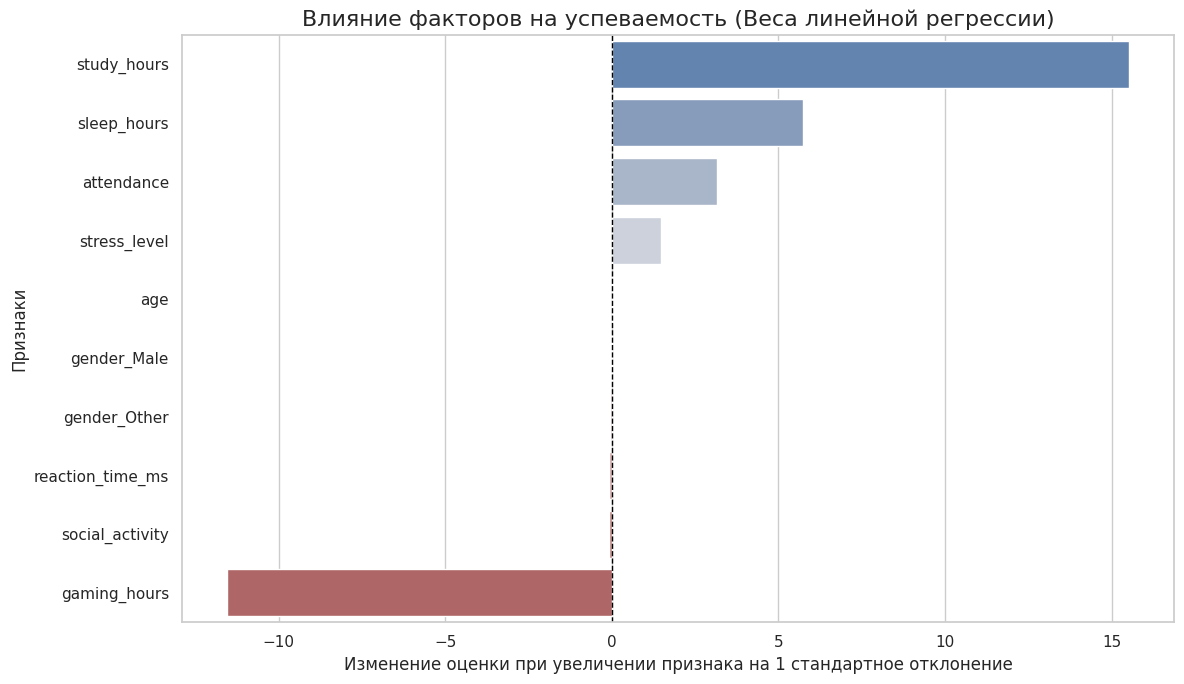

In [20]:
# Извлекаем коэффициенты и названия признаков
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Weight': lr_model.coef_
}).sort_values(by='Weight', ascending=False)

# Строим график важности признаков
plt.figure(figsize=(12, 7))
sns.barplot(data=coefficients, x='Weight', y='Feature', palette='vlag')

plt.title('Влияние факторов на успеваемость (Веса линейной регрессии)',
          fontsize=16)
plt.xlabel('Изменение оценки при увеличении признака на 1 стандартное отклонение',
           fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

**💡 Аналитический вывод по ML-модели:**

* **Высочайшая точность (R² = 0.9078):** Наша модель способна объяснить более 90% всех изменений в успеваемости студентов! Это фантастический показатель. Значение MSE = 42.87 означает, что корень из ошибки (RMSE) составляет около 6.5 баллов. То есть, зная привычки студента, мы предсказываем его балл с погрешностью всего в ~6.5 из 100.
* **Фундамент успеха (Положительные веса):** Как видно на графике, главный двигатель отличных оценок — это `study_hours` (часы учебы). Но на втором месте уверенно расположился `sleep_hours` (сон)! Здоровый сон дает мощнейший буст к успеваемости. Также модель подтвердила наш предыдущий инсайт: `stress_level` имеет положительный вес.
* **Цена гейминга (Отрицательные веса):** `gaming_hours` — главный фактор, тянущий оценку вниз. Поскольку линейная регрессия оценивает вес признака *при условии, что остальные равны* (то есть сравнивает людей с *одинаковым* количеством часов учебы и сна), мы окончательно доказали: игры вредят оценкам не потому, что "съедают" время. Они забирают когнитивный фокус, снижая КПД от последующего сидения за учебниками.
* **Равенство данных (Околонулевые веса):** Пол (`gender`), возраст (`age`), и социальная активность (`social_activity`) практически никак не влияют на балл.

## 🏆 Итоги проекта
Мы прошли путь от сырых данных до интерпретируемой модели машинного обучения и смогли перевести субъективные споры о гейминге в плоскость доказательной статистики.

**Наши главные открытия:**
1. **Реакция геймеров значительно быстрее тех, кто меньше играет в игры:** Мы статистически доказали (T-тест, p-value ≈ 0), что геймеры обладают значительно лучшей когнитивно-моторной связью, независимо от того, играют они в шутеры или RPG. Это может означать, что гейминг способствует развитию скорости реакции, или геймерами чаще становятся те, у кого быстрая реакция (по этой причине они получают преимущество в игре и остаются)
2. **Проблема не в нехватке времени:** Геймеры учатся столько же часов, сколько и остальные. **При этом оценки действительно значительно снижаются**, однако не вследствие нехватки времени, а из-за "экранного истощения", которое мешает усваивать информацию, или осознанного перераспределения приоритетов.
3. **Разрушение социального стереотипа:**
   Анализ корреляций показал, что увлечение играми никак не связано с социальной изоляцией или недосыпом. В нашей выборке геймеры имеют такую же социальную активность и спят столько же, сколько не-геймеры.
4. **Сон — скрытый драйвер успеваемости:**
   Наша ML-модель наглядно продемонстрировала, что качественный сон — второй по важности фактор для высоких оценок (сразу после самих часов учебы). Это куда важнее, чем пол, возраст или социальная активность.
5. **Стресс как следствие вовлеченности (академическая нагрузка):**
   Студенты с высокими оценками показывают более высокий уровень стресса. Мы приходим к логичному выводу: стресс в данном случае — это закономерное *следствие* интенсивной учебы и чувства ответственности, а не причина выгорания. В то же время "беззаботная" группа с низким стрессом получает плохие оценки просто из-за отсутствия интереса к учебе.
---
*Дорожная карта выполнена точно в срок. Проект успешно завершен 20.05.2026. Спасибо за внимание!*